In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv(r"E:\Innomatics\Flight Delay Analysis\Sprint2\Flight_Delays_Cleaned_v2.csv")

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50000
Columns: 30


In [5]:
df.head()

,date_of_journey,month,day_of_week,airline,flight_number,tail_number,origin_airport,destination_airport,scheduled_departure,departure_time,...,arrival_time,arrival_delay,diverted,cancelled,cancellation_reason,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay
0,2015-05-14,May,Thursday,US,1721,N174US,CLT,SMF,18:10:00,18:30:00,...,20:43:00,4.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
1,2015-11-29,November,Sunday,MQ,3363,N902MQ,LEX,ORD,18:37:00,19:06:00,...,19:42:00,17.0,0,0,Not Cancelled,0.0,0.0,0.0,17.0,0.0
2,2015-02-10,February,Tuesday,US,1933,N562UW,PHL,ORD,07:30:00,07:25:00,...,08:34:00,-28.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
3,2015-12-21,December,Monday,UA,1929,N460UA,SEA,EWR,06:22:00,06:23:00,...,14:14:00,-17.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
4,2015-05-07,May,Thursday,DL,1478,N67171,ATL,PHL,07:25:00,07:28:00,...,09:20:00,-5.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0


In [6]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (50000, 30)

Column names:
['date_of_journey', 'month', 'day_of_week', 'airline', 'flight_number', 'tail_number', 'origin_airport', 'destination_airport', 'scheduled_departure', 'departure_time', 'departure_delay', 'taxi_out', 'takeoff_time', 'scheduled_time', 'elapsed_time', 'air_time', 'distance', 'landing_time', 'taxi_in', 'scheduled_arrival', 'arrival_time', 'arrival_delay', 'diverted', 'cancelled', 'cancellation_reason', 'air_system_delay', 'security_delay', 'airline_delay', 'late_aircraft_delay', 'weather_delay']

Data types:
date_of_journey         object
month                   object
day_of_week             object
airline                 object
flight_number            int64
tail_number             object
origin_airport          object
destination_airport     object
scheduled_departure     object
departure_time          object
departure_delay        float64
taxi_out               float64
takeoff_time            object
scheduled_time         float64
elapsed_ti

In [ ]:
df.isnull().sum()

date_of_journey          0
month                    0
day_of_week              0
airline                  0
flight_number            0
tail_number              0
origin_airport           0
destination_airport      0
scheduled_departure      0
departure_time         768
departure_delay        766
taxi_out               785
takeoff_time           787
scheduled_time           0
elapsed_time           915
air_time               915
distance                 0
landing_time           842
taxi_in                818
scheduled_arrival        0
arrival_time           834
arrival_delay          915
diverted                 0
cancelled                0
cancellation_reason      0
air_system_delay         0
security_delay           0
airline_delay            0
late_aircraft_delay      0
weather_delay            0
dtype: int64

**Descriptive Analysis**

In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].describe()

,flight_number,departure_delay,taxi_out,scheduled_time,elapsed_time,air_time,distance,taxi_in,arrival_delay,diverted,cancelled,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay
count,50000.000000,49234.000000,49215.000000,50000.000000,49085.000000,49085.000000,50000.000000,49182.000000,49085.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2177.016720,9.086526,16.019344,141.922720,137.222308,113.813589,824.202920,7.406043,3.99945,0.002420,0.015880,2.408300,0.013000,3.352280,4.119340,0.528820
std,1759.888911,35.464728,8.805555,75.597348,74.545514,72.559381,611.888335,5.611428,37.75498,0.049134,0.125013,12.529032,0.765508,20.532381,19.659122,8.584775
min,1.000000,-55.000000,1.000000,21.000000,17.000000,9.000000,31.000000,1.000000,-70.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,733.000000,-5.000000,11.000000,85.000000,82.000000,61.000000,373.000000,4.000000,-13.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1686.000000,-2.000000,14.000000,123.000000,118.000000,94.000000,646.000000,6.000000,-5.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3246.000000,7.000000,19.000000,174.000000,169.000000,144.000000,1066.000000,9.000000,8.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8410.000000,1515.000000,149.000000,679.000000,715.000000,654.000000,4983.000000,165.000000,1574.00000,1.000000,1.000000,532.000000,129.000000,1515.000000,765.000000,510.000000


Measures of Central Tendency

In [9]:
print("Mean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nMode:")
print(df[numeric_columns].mode().iloc[0])

Mean:
flight_number          2177.016720
departure_delay           9.086526
taxi_out                 16.019344
scheduled_time          141.922720
elapsed_time            137.222308
air_time                113.813589
distance                824.202920
taxi_in                   7.406043
arrival_delay             3.999450
diverted                  0.002420
cancelled                 0.015880
air_system_delay          2.408300
security_delay            0.013000
airline_delay             3.352280
late_aircraft_delay       4.119340
weather_delay             0.528820
dtype: float64

Median:
flight_number          1686.0
departure_delay          -2.0
taxi_out                 14.0
scheduled_time          123.0
elapsed_time            118.0
air_time                 94.0
distance                646.0
taxi_in                   6.0
arrival_delay            -5.0
diverted                  0.0
cancelled                 0.0
air_system_delay          0.0
security_delay            0.0
airline_delay       

Measures of Dispersion

In [10]:
print("Standard Deviation:")
print(df[numeric_columns].std())

print("\nVariance:")
print(df[numeric_columns].var())

print("\nRange:")
print(df[numeric_columns].max() - df[numeric_columns].min())

Standard Deviation:
flight_number          1759.888911
departure_delay          35.464728
taxi_out                  8.805555
scheduled_time           75.597348
elapsed_time             74.545514
air_time                 72.559381
distance                611.888335
taxi_in                   5.611428
arrival_delay            37.754980
diverted                  0.049134
cancelled                 0.125013
air_system_delay         12.529032
security_delay            0.765508
airline_delay            20.532381
late_aircraft_delay      19.659122
weather_delay             8.584775
dtype: float64

Variance:
flight_number          3.097209e+06
departure_delay        1.257747e+03
taxi_out               7.753781e+01
scheduled_time         5.714959e+03
elapsed_time           5.557034e+03
air_time               5.264864e+03
distance               3.744073e+05
taxi_in                3.148812e+01
arrival_delay          1.425438e+03
diverted               2.414192e-03
cancelled              1.562814e-0

**Univariate Analysis**

Skewness

In [11]:
skewness = df[numeric_columns].skew()

print("Skewness of numerical variables:")
print(skewness.sort_values(ascending=False))

Skewness of numerical variables:
security_delay         113.485577
weather_delay           30.310056
diverted                20.254634
airline_delay           20.006577
air_system_delay        12.103493
late_aircraft_delay      8.815818
cancelled                7.745452
departure_delay          7.267481
arrival_delay            6.389632
taxi_in                  5.419895
taxi_out                 3.388788
distance                 1.454148
air_time                 1.406082
elapsed_time             1.380503
scheduled_time           1.367666
flight_number            0.855095
dtype: float64


In [ ]:
#airline
df["airline"].value_counts(ascending=False)

airline
WN    10946
DL     7488
AA     6208
OO     4993
EV     4969
UA     4344
MQ     2559
B6     2319
US     1701
AS     1515
NK      990
F9      750
HA      678
VX      540
Name: count, dtype: int64

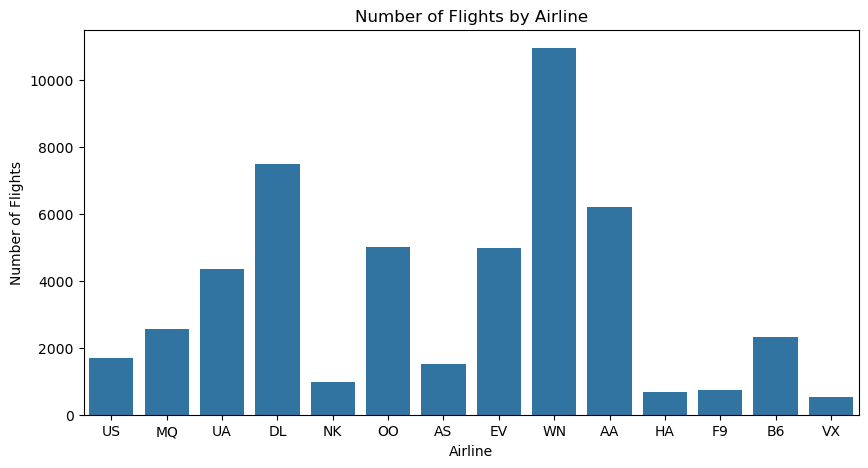

In [17]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="airline")

plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.show()

In [ ]:
#Month Distribution
df["month"].value_counts()

month
July         4446
August       4423
June         4406
March        4317
May          4236
October      4228
April        4213
December     4093
November     4059
September    3998
January      3942
February     3639
Name: count, dtype: int64

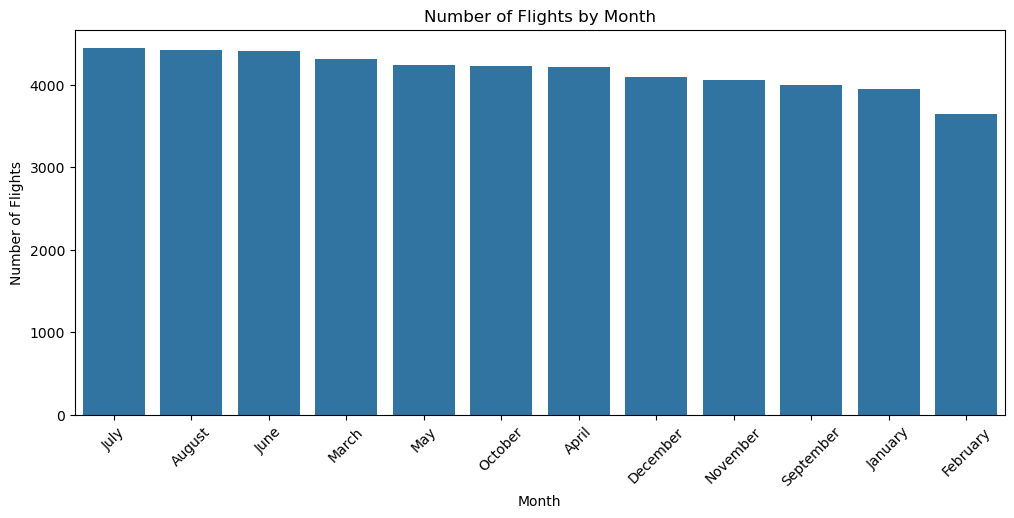

In [20]:
plt.figure(figsize=(12, 5))

sns.countplot(data=df, x="month", order=df["month"].value_counts().index)

plt.title("Number of Flights by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)

plt.show()

In [22]:
# Cancellation Distribution
df["cancelled"].value_counts()

cancelled
0    49206
1      794
Name: count, dtype: int64

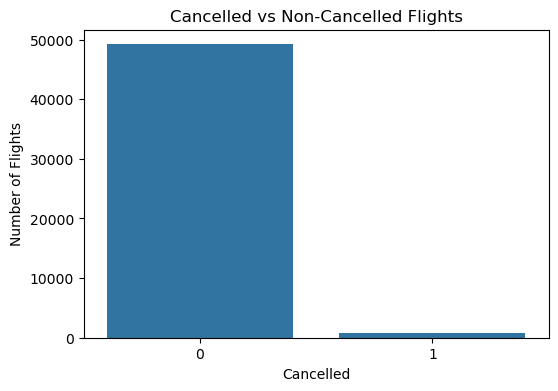

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="cancelled")

plt.title("Cancelled vs Non-Cancelled Flights")
plt.xlabel("Cancelled")
plt.ylabel("Number of Flights")

plt.show()

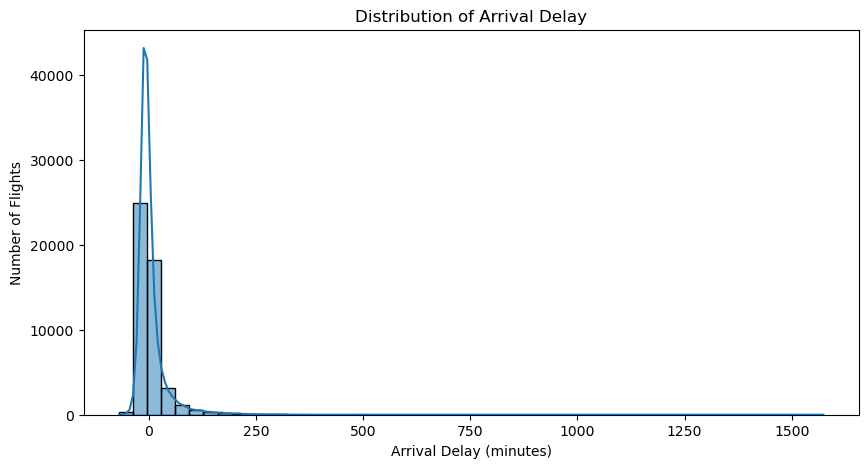

In [24]:
# Arrival Delay Distribution
plt.figure(figsize=(10, 5))

sns.histplot(df["arrival_delay"].dropna(), bins=50, kde=True)

plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

plt.show()

**Bivariate Analysis**

Airline vs Arrival Delay

In [ ]:
airline_delay = (
    df.groupby("airline", observed=True)["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
)

print(airline_delay)

airline
NK    14.507677
F9    10.403509
VX     7.042831
EV     6.514786
MQ     6.504746
B6     5.862357
OO     5.100737
WN     4.385050
UA     4.344868
US     2.910349
AA     2.253574
HA     1.084570
DL     0.258801
AS    -1.172071
Name: arrival_delay, dtype: float64


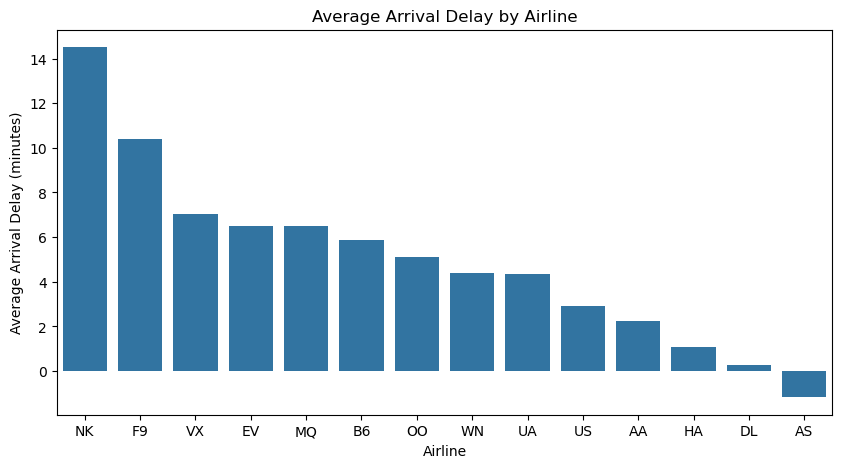

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=airline_delay.index,
    y=airline_delay.values
)

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (minutes)")

plt.show()

Airline vs Cancellation Rate

In [27]:
cancellation_rate = (
    df.groupby("airline", observed=True)["cancelled"]
    .mean() * 100
)

cancellation_rate = cancellation_rate.sort_values(ascending=False)

print(cancellation_rate)

airline
MQ    5.119187
EV    3.018716
US    1.998824
OO    1.902664
B6    1.681759
AA    1.675258
UA    1.358195
WN    1.160241
NK    1.111111
F9    0.666667
HA    0.589971
DL    0.413996
VX    0.370370
AS    0.132013
Name: cancelled, dtype: float64


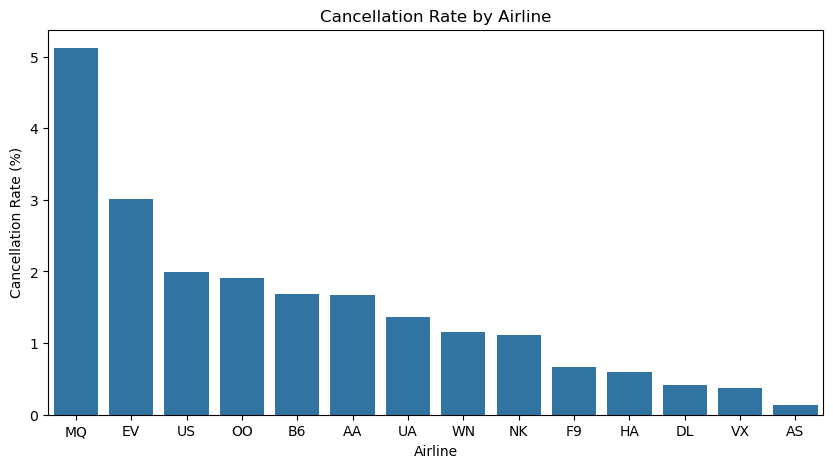

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=cancellation_rate.index,
    y=cancellation_rate.values
)

plt.title("Cancellation Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Cancellation Rate (%)")

plt.show()

Departure Delay vs Arrival Delay

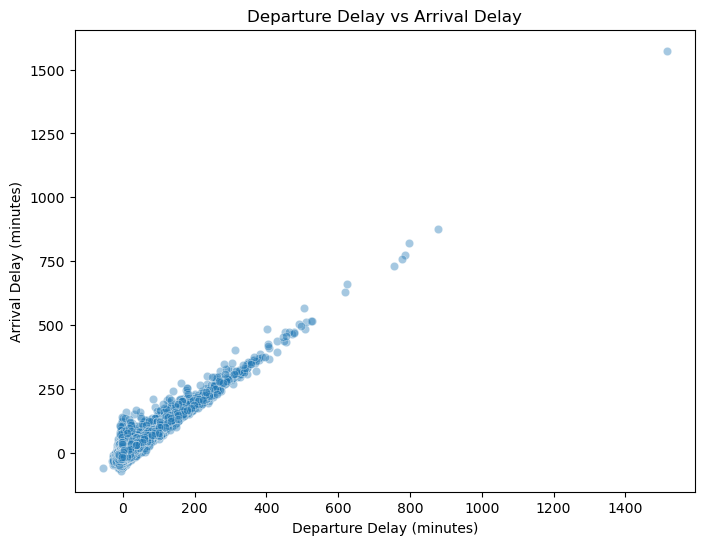

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="departure_delay",
    y="arrival_delay",
    alpha=0.4
)

plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.show()

Flight Distance vs Arrival Delay

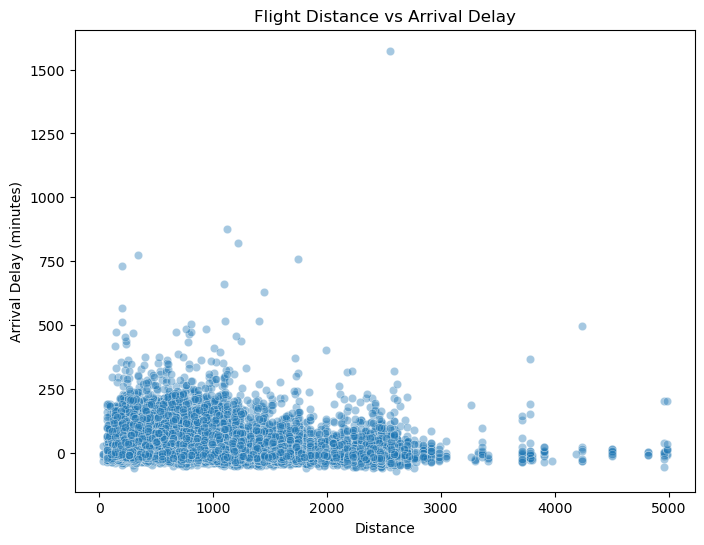

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="arrival_delay",
    alpha=0.4
)

plt.title("Flight Distance vs Arrival Delay")
plt.xlabel("Distance")
plt.ylabel("Arrival Delay (minutes)")

plt.show()

Month vs Arrival Delay

In [ ]:
month_delay = (
    df.groupby("month", observed=True)["arrival_delay"]
    .mean()
)

print(month_delay)

month
April        2.472885
August       4.256881
December     4.950562
February     9.765964
January      5.763589
July         5.736782
June         9.475793
March        4.051154
May          2.848405
November     1.103886
October     -1.297239
September   -0.568228
Name: arrival_delay, dtype: float64


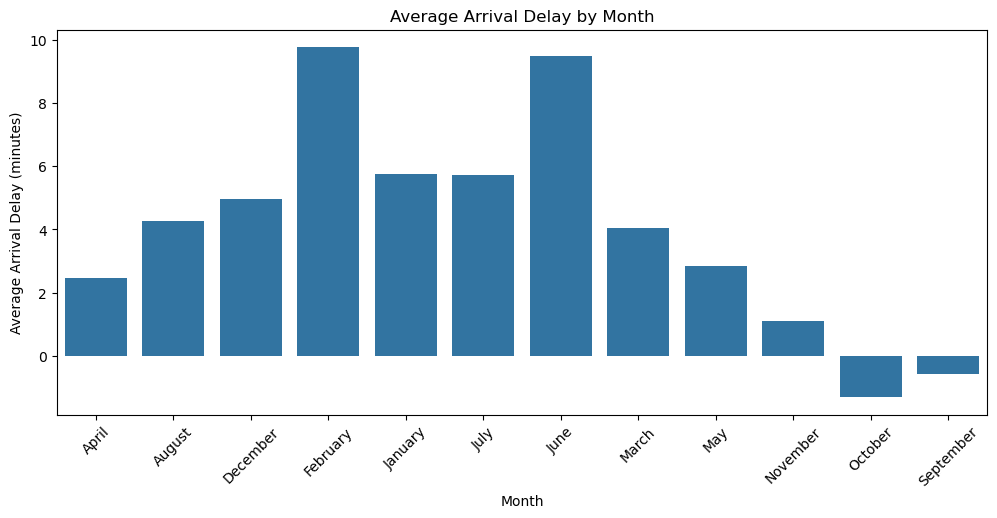

In [33]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=month_delay.index,
    y=month_delay.values
)

plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (minutes)")

plt.xticks(rotation=45)

plt.show()

Day of Week vs Arrival Delay

In [ ]:
day_delay = (
    df.groupby("day_of_week", observed=True)["arrival_delay"]
    .mean()
)

print(day_delay)

day_of_week
Friday       4.825833
Monday       5.417732
Saturday     1.106215
Sunday       3.708250
Thursday     5.439434
Tuesday      3.816767
Wednesday    3.094443
Name: arrival_delay, dtype: float64


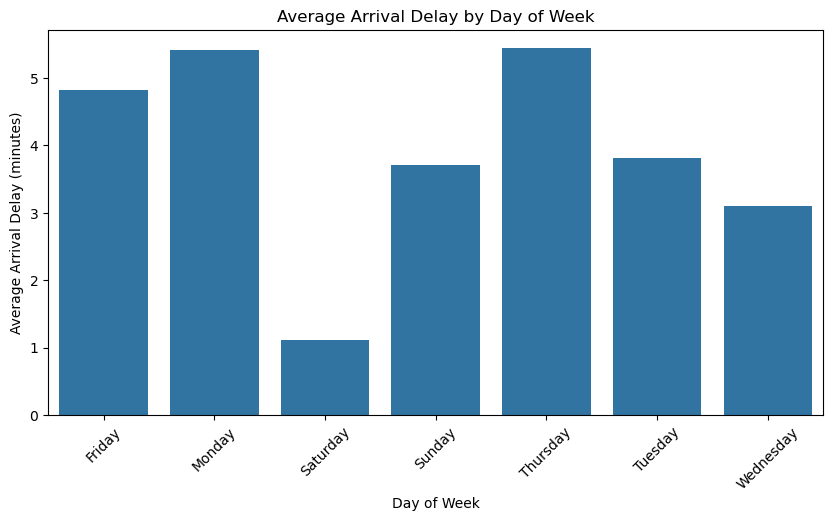

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_delay.index,
    y=day_delay.values
)

plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Arrival Delay (minutes)")

plt.xticks(rotation=45)

plt.show()

Airport vs Delay

In [ ]:
#origin_airport
#Because you have both origin and destination airports, analyze them separately.

origin_delay = (
    df.groupby("origin_airport", observed=True)["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
)

print(origin_delay.head(10))

origin_airport
BJI      149.2
10279    105.0
10732     93.0
10577     82.0
12898     68.0
13277     61.0
11150     52.5
12888     47.0
13970     40.5
SUX       38.0
Name: arrival_delay, dtype: float64


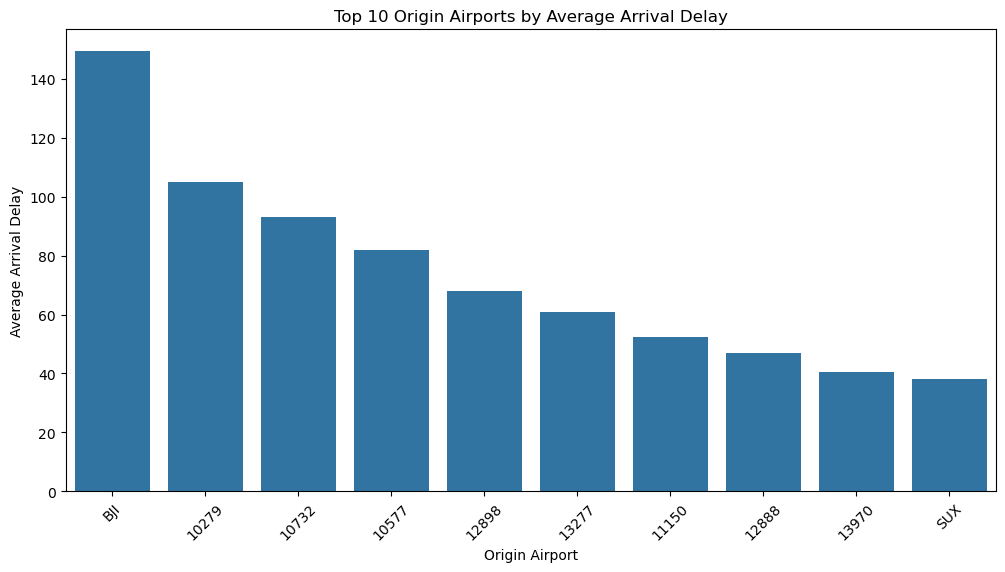

In [39]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=origin_delay.head(10).index,
    y=origin_delay.head(10).values
)

plt.title("Top 10 Origin Airports by Average Arrival Delay")
plt.xlabel("Origin Airport")
plt.ylabel("Average Arrival Delay")

plt.xticks(rotation=45)

plt.show()

**Group-Based Analysis**

Airline Summary

In [40]:
airline_summary = df.groupby("airline", observed=True).agg(
    total_flights=("airline", "count"),
    average_departure_delay=("departure_delay", "mean"),
    average_arrival_delay=("arrival_delay", "mean"),
    cancellation_rate=("cancelled", "mean")
)

airline_summary["cancellation_rate"] = (
    airline_summary["cancellation_rate"] * 100
)

airline_summary

,total_flights,average_departure_delay,average_arrival_delay,cancellation_rate
airline,,,,
AA,6208,7.950213,2.253574,1.675258
AS,1515,1.856576,-1.172071,0.132013
B6,2319,10.757895,5.862357,1.681759
DL,7488,7.284163,0.258801,0.413996
EV,4969,8.586493,6.514786,3.018716
F9,750,12.120805,10.403509,0.666667
HA,678,-0.485926,1.084570,0.589971
MQ,2559,10.366475,6.504746,5.119187
NK,990,15.511747,14.507677,1.111111


In [8]:
monthly_summary = df.groupby("month", observed=True).agg(
    total_flights=("airline", "count"),
    average_departure_delay=("departure_delay", "mean"),
    average_arrival_delay=("arrival_delay", "mean"),
    cancellation_rate=("cancelled", "mean")
)

monthly_summary["cancellation_rate"] *= 100

monthly_summary

,total_flights,average_departure_delay,average_arrival_delay,cancellation_rate
month,,,,
April,4213,7.138155,2.472885,1.258011
August,4423,9.964816,4.256881,1.107845
December,4093,10.406273,4.950562,1.905693
February,3639,13.233429,9.765964,4.699093
January,3942,10.165671,5.763589,2.359209
July,4446,11.009089,5.736782,1.057130
June,4406,13.919225,9.475793,1.747617
March,4317,9.012790,4.051154,2.316423
May,4236,8.016726,2.848405,1.274788


In [42]:
# Day-of-Week Summary
weekday_summary = df.groupby("day_of_week", observed=True).agg(
    total_flights=("airline", "count"),
    average_arrival_delay=("arrival_delay", "mean"),
    cancellation_rate=("cancelled", "mean")
)

weekday_summary["cancellation_rate"] *= 100

weekday_summary


,total_flights,average_arrival_delay,cancellation_rate
day_of_week,,,
Friday,7275,4.825833,0.907216
Monday,7410,5.417732,2.564103
Saturday,6052,1.106215,1.140119
Sunday,7169,3.708250,1.618078
Thursday,7690,5.439434,1.365410
Tuesday,7158,3.816767,1.983794
Wednesday,7246,3.094443,1.462876


In [4]:
# Cancellation Reason Analysis
df["cancellation_reason"].value_counts()

cancellation_reason
Not Cancelled    49206
B                  432
A                  215
C                  146
D                    1
Name: count, dtype: int64

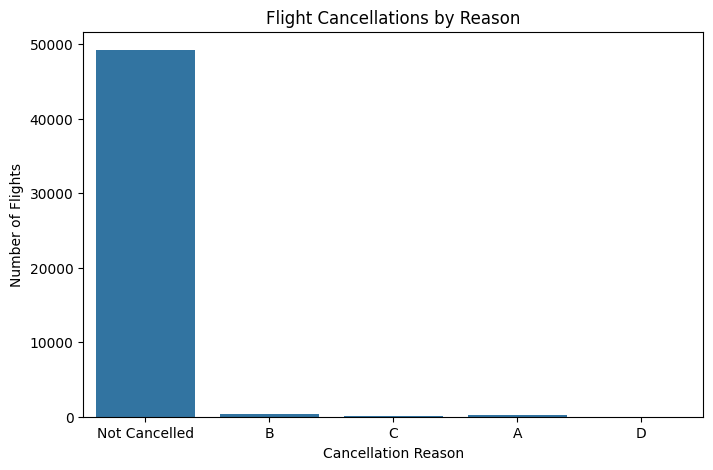

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="cancellation_reason"
)

plt.title("Flight Cancellations by Reason")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Flights")

plt.show()

Pivot Tables

In [7]:
# Airline vs Delay
pivot_airline = pd.pivot_table(
    df,
    values="arrival_delay",
    index="airline",
    aggfunc="mean"
)

pivot_airline

,arrival_delay
airline,
AA,2.253574
AS,-1.172071
B6,5.862357
DL,0.258801
EV,6.514786
F9,10.403509
HA,1.084570
MQ,6.504746
NK,14.507677


In [8]:
# Month vs Airline
pivot_month_airline = pd.pivot_table(
    df,
    values="arrival_delay",
    index="month",
    columns="airline",
    aggfunc="mean"
)

pivot_month_airline

airline,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
month,,,,,,,,,,,,,,
April,6.992208,-2.438017,3.689474,-0.829889,4.244019,12.400000,0.415094,5.235294,5.550562,0.607235,4.718475,-1.779359,0.945946,2.256137
August,4.774194,3.364286,7.329843,0.383901,3.002457,1.676056,2.403846,3.580488,21.908046,7.594406,3.321716,NaN,7.057143,4.036885
December,2.176656,-0.783217,13.185930,0.557047,7.838440,2.972973,-5.574468,-1.856287,13.654321,8.470437,5.636656,NaN,12.606061,6.760288
February,11.687097,2.122807,26.213415,7.263804,13.008571,24.351351,5.298246,19.417910,23.367647,10.151261,7.433566,8.227092,19.965517,3.264706
January,6.356568,-0.980583,9.464865,-2.242144,7.467470,18.627451,4.206349,20.286364,7.904110,9.390746,6.684713,0.755396,5.800000,4.756250
July,3.295031,-0.530864,1.694175,0.772926,4.856148,10.916667,1.780000,1.941704,13.723684,6.958525,9.818182,NaN,3.818182,11.161826
June,3.490862,-2.716667,4.767956,7.821321,12.635714,24.930556,-0.203390,13.742081,35.500000,5.250000,14.115090,5.936306,11.454545,11.403826
March,2.936675,1.476923,4.727749,1.254717,6.857143,14.193548,3.016129,10.985782,15.387500,0.408989,1.605114,4.464945,5.609756,4.614865
May,0.423077,-4.601770,-0.056180,-1.386431,9.252336,16.424242,-2.232143,2.630332,19.531250,3.616188,0.905714,-0.044944,1.684211,4.455738


In [15]:
# Airport vs Airline
pivot_airport_airline = pd.pivot_table(
    df,
    values="arrival_delay",
    index="origin_airport",
    columns="airline",
    aggfunc="mean"
)

pivot_airport_airline.tail(100)

airline,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
origin_airport,,,,,,,,,,,,,,
MYR,NaN,NaN,NaN,-2.625000,-1.777778,NaN,NaN,NaN,6.777778,NaN,NaN,NaN,NaN,NaN
OAJ,NaN,NaN,NaN,NaN,13.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OAK,-10.000000,-3.714286,0.0,-6.400000,NaN,NaN,1.200000,NaN,-0.300000,3.588235,NaN,2.5,NaN,7.16388
OGG,-15.550000,-7.360000,NaN,36.166667,NaN,NaN,2.855856,NaN,NaN,NaN,-8.095238,5.0,NaN,NaN
OKC,-7.315789,NaN,NaN,25.294118,-1.357143,86.0,NaN,6.705882,NaN,15.947368,32.166667,NaN,NaN,1.25000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WRG,NaN,21.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WYS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.666667,NaN,NaN,NaN,NaN
XNA,NaN,NaN,NaN,-3.571429,13.852941,NaN,NaN,5.583333,NaN,-4.166667,NaN,NaN,NaN,NaN


Cross Tab Analysis

In [16]:
# Airline vs Cancellation Reason
reason_crosstab = pd.crosstab(
    df["airline"],
    df["cancellation_reason"]
)

reason_crosstab

cancellation_reason,A,B,C,D,Not Cancelled
airline,,,,,
AA,29,70,5,0,6104
AS,1,1,0,0,1513
B6,8,21,10,0,2280
DL,4,25,2,0,7457
EV,39,57,54,0,4819
F9,2,3,0,0,745
HA,4,0,0,0,674
MQ,23,70,37,1,2428
NK,2,7,2,0,979


In [17]:
df["delay_status"] = np.where(
    df["arrival_delay"] > 0,
    "Delayed",
    "On Time/Early"
)

df["delay_status"].value_counts()

delay_status
On Time/Early    32142
Delayed          17858
Name: count, dtype: int64

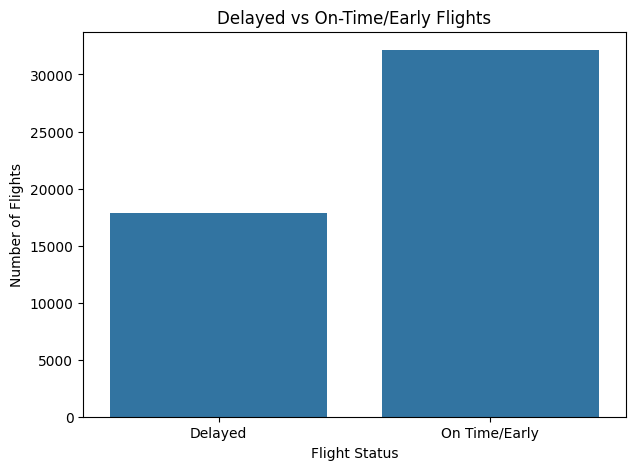

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="delay_status"
)

plt.title("Delayed vs On-Time/Early Flights")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")

plt.show()

In [ ]:
# Airline vs Cancelled
ct_airline_cancel = pd.crosstab(df["airline"], df["cancelled"], normalize="index") * 100
ct_airline_cancel.columns = ["Not Cancelled %", "Cancelled %"]
ct_airline_cancel.round(2).sort_values("Cancelled %", ascending=False)

,Not Cancelled %,Cancelled %
airline,,
MQ,94.88,5.12
EV,96.98,3.02
US,98.00,2.00
OO,98.10,1.90
B6,98.32,1.68
AA,98.32,1.68
UA,98.64,1.36
WN,98.84,1.16
NK,98.89,1.11


Multivariate Analysis

air_system_delay       120415.0
security_delay            650.0
airline_delay          167614.0
late_aircraft_delay    205967.0
weather_delay           26441.0
dtype: float64


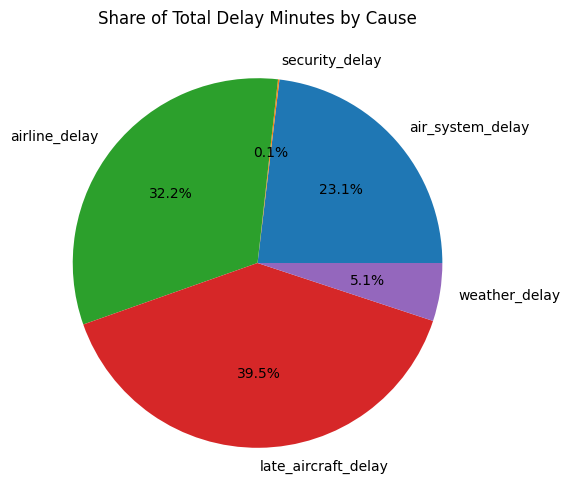

In [ ]:
import matplotlib.pyplot as plt

delay_columns = [
    "air_system_delay",
    "security_delay",
    "airline_delay",
    "late_aircraft_delay",
    "weather_delay"
]

# Find the total delay for each cause
total_delay = df[delay_columns].sum()
print(total_delay)

plt.figure(figsize=(8, 6))

plt.pie(
    total_delay,
    labels=total_delay.index,
    autopct="%1.1f%%"
)

plt.title("Share of Total Delay Minutes by Cause")
plt.show()

In [22]:
fig = px.box(
    df,
    x="month",
    y="arrival_delay",
    color="airline",
    title="Arrival Delay by Month and Airline",
    labels={
        "month": "Month",
        "arrival_delay": "Arrival Delay (minutes)",
        "airline": "Airline"
    }
)

fig.update_layout(
    width=1000,
    height=600
)

fig.show()

Correlation Analysis

In [23]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,flight_number,departure_delay,taxi_out,scheduled_time,elapsed_time,air_time,distance,taxi_in,arrival_delay,diverted,cancelled,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay
flight_number,1.000000,-0.005431,0.053753,-0.314462,-0.302983,-0.315802,-0.328294,-0.027337,0.022463,0.006210,0.045809,0.007283,-0.007791,0.005616,0.006126,0.005480
departure_delay,-0.005431,1.000000,0.067619,0.027878,0.032584,0.025157,0.024681,0.001050,0.940819,0.029479,0.043351,0.308403,0.023957,0.645738,0.649086,0.269738
taxi_out,0.053753,0.067619,1.000000,0.116529,0.205160,0.089638,0.075842,-0.001215,0.236572,0.016991,-0.003784,0.333465,0.002792,0.048199,0.030032,0.085393
scheduled_time,-0.314462,0.027878,0.116529,1.000000,0.985615,0.990697,0.984401,0.102346,-0.033157,0.010195,-0.034961,0.007909,0.007234,0.021984,-0.014514,-0.002189
elapsed_time,-0.302983,0.032584,0.205160,0.985615,1.000000,0.990349,0.973930,0.158150,0.027993,NaN,NaN,0.079898,0.008475,0.028222,-0.009690,0.009619
air_time,-0.315802,0.025157,0.089638,0.990697,0.990349,1.000000,0.985471,0.085770,-0.008189,NaN,NaN,0.026246,0.007749,0.023095,-0.014325,-0.001055
distance,-0.328294,0.024681,0.075842,0.984401,0.973930,0.985471,1.000000,0.078291,-0.027972,0.007973,-0.039692,0.001136,0.007009,0.020991,-0.013203,-0.004410
taxi_in,-0.027337,0.001050,-0.001215,0.102346,0.158150,0.085770,0.078291,1.000000,0.107612,0.038844,NaN,0.197260,0.007944,0.000058,0.008679,0.007049
arrival_delay,0.022463,0.940819,0.236572,-0.033157,0.027993,-0.008189,-0.027972,0.107612,1.000000,NaN,NaN,0.433904,0.024830,0.620486,0.623057,0.277813
diverted,0.006210,0.029479,0.016991,0.010195,NaN,NaN,0.007973,0.038844,NaN,1.000000,-0.006257,-0.009467,-0.000836,-0.008042,-0.010321,-0.003034


In [ ]:
# Correlation With Arrival Delay
arrival_correlations = (
    correlation["arrival_delay"]
    .sort_values(ascending=False)
)

print(arrival_correlations)

arrival_delay          1.000000
departure_delay        0.940819
late_aircraft_delay    0.623057
airline_delay          0.620486
air_system_delay       0.433904
weather_delay          0.277813
taxi_out               0.236572
taxi_in                0.107612
elapsed_time           0.027993
security_delay         0.024830
flight_number          0.022463
air_time              -0.008189
distance              -0.027972
scheduled_time        -0.033157
diverted                    NaN
cancelled                   NaN
Name: arrival_delay, dtype: float64


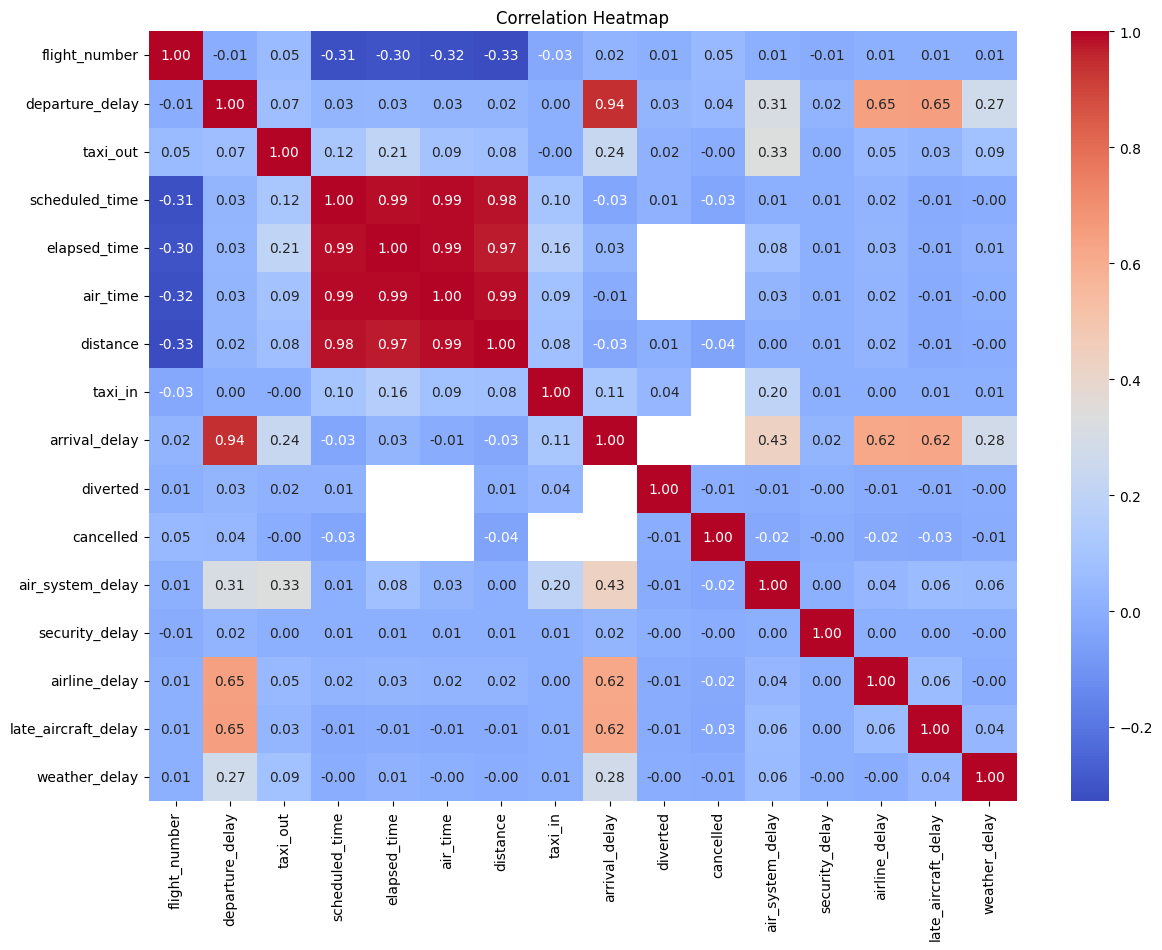

In [25]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

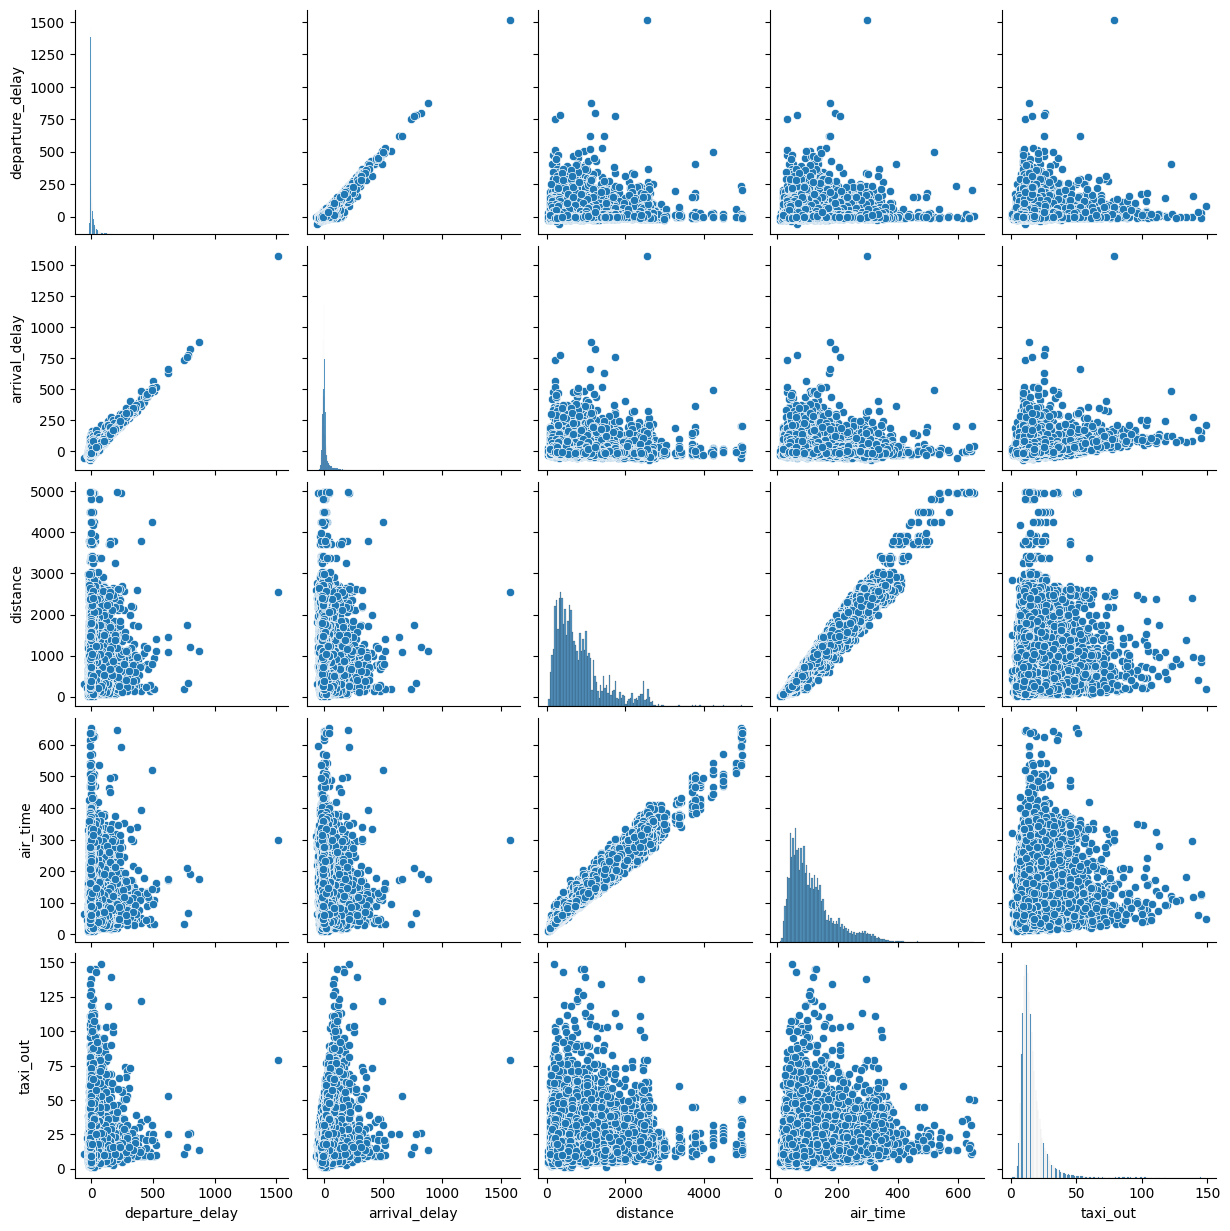

In [6]:
# Pair Plot
pair_columns = [
    "departure_delay",
    "arrival_delay",
    "distance",
    "air_time",
    "taxi_out"
]

sns.pairplot(
    df[pair_columns].dropna()
)

plt.show()

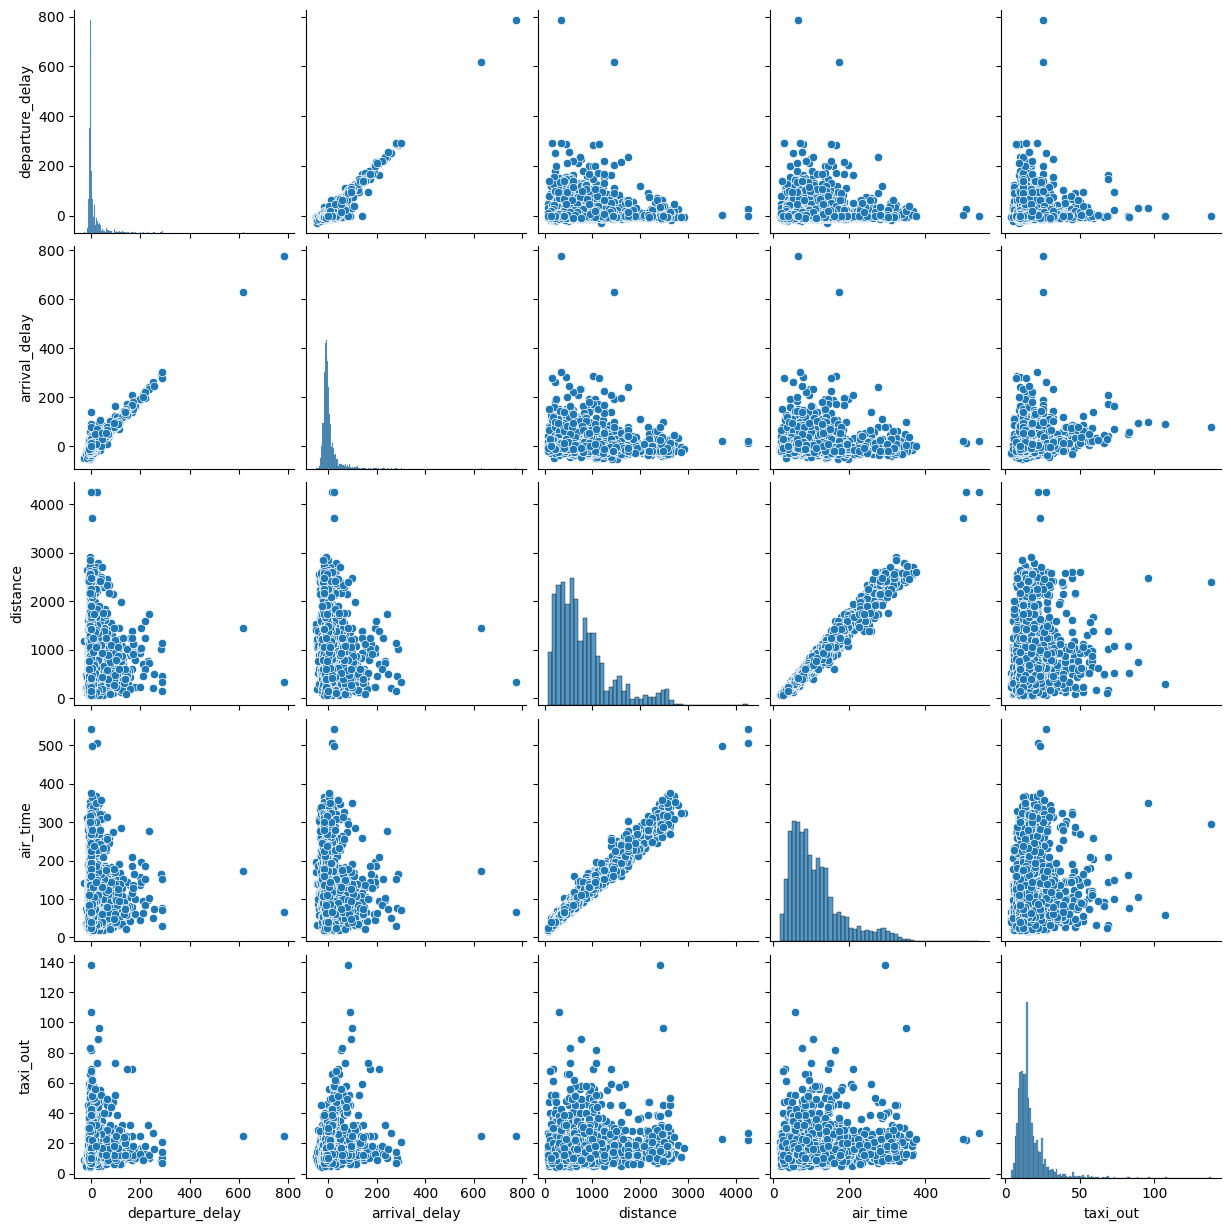

In [7]:
sample_df = df[pair_columns].dropna().sample(
    3000,
    random_state=42
)

sns.pairplot(sample_df)

plt.show()